In [ ]:
import pandas as Dimen_ReductPn
import warnings as Dimen_ReductWn
Dimen_ReductWn.filterwarnings("ignore")

In [ ]:
Dimen_Reduct = Dimen_ReductPn.read_csv('NumericalData_DimensionalityReduction.csv')
Dimen_Reduct

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100083,0,0,1,0,1,0,103500.0,573628.5,24435.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
1,100145,0,0,0,0,1,1,202500.0,260725.5,16789.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100179,0,0,0,0,0,0,202500.0,675000.0,53329.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,4.0
3,100190,0,0,1,0,0,0,162000.0,263686.5,24781.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100295,1,0,1,0,0,1,225000.0,1019205.0,31032.0,...,1,0,0,0,0.0,0.0,0.0,6.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8597,456083,0,0,0,0,1,2,112500.0,361462.5,16051.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0
8598,456084,0,0,0,0,1,1,99000.0,675000.0,21906.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8599,456140,1,0,0,0,1,1,261000.0,711454.5,47673.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
8600,456195,0,0,0,0,1,0,94500.0,270000.0,15075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0


In [ ]:
Dimen_Reduct['TARGET'].value_counts()

,count
TARGET,
0,8076
1,526


In [ ]:
Dimen_Reduct.shape

(8602, 122)

In [ ]:
DimenRedctXa = Dimen_Reduct.drop(['TARGET'], axis=1)
DimenRedctYa = Dimen_Reduct['TARGET']

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE as Dimen_ReductSM
from collections import Counter as Dimen_ReductCCnt

In [ ]:
###@@@ ---- Oversampling process of Smote using Numerical data ----###@@@

print('Numerical Data Shape      : %s' % Dimen_ReductCCnt(DimenRedctYa))
Dimenredmd= Dimen_ReductSM()
DimenRedctXa, DimenRedctYa = Dimenredmd.fit_resample(DimenRedctXa, DimenRedctYa)
print('Oversampled Data Shape : %s' % Dimen_ReductCCnt(DimenRedctYa))

Numerical Data Shape      : Counter({0: 8076, 1: 526})
Oversampled Data Shape : Counter({0: 8076, 1: 8076})


In [ ]:
###@@@@--- using Mini-Batch SparsePCA Dimensionaly Reduction----###@@@

from sklearn.decomposition import MiniBatchSparsePCA as Dimen_ReductmnbsprPCA
import numpy as Dimen_Reductnu
import matplotlib.pyplot as Dimen_ReductMn

In [ ]:
dimenrdsprpca = Dimen_ReductmnbsprPCA(n_components=10, random_state=25)
DimenRedctXa = dimenrdsprpca.fit_transform(DimenRedctXa)

In [ ]:
Dimen_ReductMn = Dimen_ReductmnbsprPCA(n_components = 15)
DimenRedctXa= Dimen_ReductMn.fit_transform(DimenRedctXa)
DimenRedctXa

array([[1002242.36368095,  816503.35007822, -231112.50631445, ...,
         -78351.76852773,  -67371.13812098,   37680.29759245],
       [ 960810.15335077,  558160.84770296,   75677.41940934, ...,
         -80587.61633207,  -64760.06491109,   53227.80522358],
       [ 845613.73520601,  731861.26147134,   16431.14862203, ...,
         -43566.50595543,  -30922.72532982,   89213.93770323],
       ...,
       [-728091.15358026, -617860.47225387,   92918.78257453, ...,
          51009.26760487,   41853.7426471 ,  -45468.73465368],
       [ 742913.01977123,  655469.91559463,  -51159.43566321, ...,
         -38731.59726598,  -29265.81377515,   64758.08788217],
       [ 537017.73584128,  331072.99373037,   33005.64386936, ...,
         -38007.88741416,  -30229.28963073,   29799.79757301]])

In [ ]:
from sklearn.model_selection import train_test_split as Dimen_Reducttspt

###@@@@ ---- split the data into Training 60%, va/ 20%, test 20% ----###@@@
DimenRedctXatrn, DimenRedctXatst, DimenRedctYatrn, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXa, DimenRedctYa, test_size=0.2, random_state=25)
print("Shape of Train data (numerical features)  :", DimenRedctXatrn.shape)

Shape of Train data (numerical features)  : (12921, 15)


In [ ]:
DimenRedctXavl, DimenRedctXatst, DimenRedctYavl, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXatst, DimenRedctYatst, test_size=0.5, random_state=25)

print("Shape of Val data (numerical features)  :", DimenRedctXavl.shape)
print("Shape of Test data (numerical features)  :", DimenRedctXatst.shape)

Shape of Val data (numerical features)  : (1615, 15)
Shape of Test data (numerical features)  : (1616, 15)


In [ ]:
import time as Dimen_Reductm
from sklearn import metrics as Dimen_Reductmcs
from sklearn.model_selection import GridSearchCV as Dimen_Reductgrdsh
from sklearn.metrics import confusion_matrix as Dimen_Reductcnmx
import matplotlib.pyplot as Dimen_ReductMn
from sklearn.metrics import ConfusionMatrixDisplay as Dimen_Reductcnmxdp
from sklearn.metrics import classification_report as Dimen_Reductrpt

#Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression as Dimen_ReductLrc

Dimen_Reducthyprms = {
                       'penalty' : ['l1', 'l2', 'elasticnet'],
                       'C' : [0.1, 0.01, 0.5, 0.8, 1.0],
                       'solver' : [ 'liblinear', 'saga']
                      }

Dimenredmd = Dimen_ReductLrc(max_iter=1000)
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- LR:")
print(Dimenredmd.best_params_)

best Params -- LR:
{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductLrc(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--LR classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--LR classifier   : 20.66333842277527 



              precision    recall  f1-score   support

           0       0.58      0.54      0.56       805
           1       0.57      0.62      0.59       810

    accuracy                           0.58      1615
   macro avg       0.58      0.58      0.58      1615
weighted avg       0.58      0.58      0.58      1615


Validate Time--LR Classifier : 0.01813030242919922 



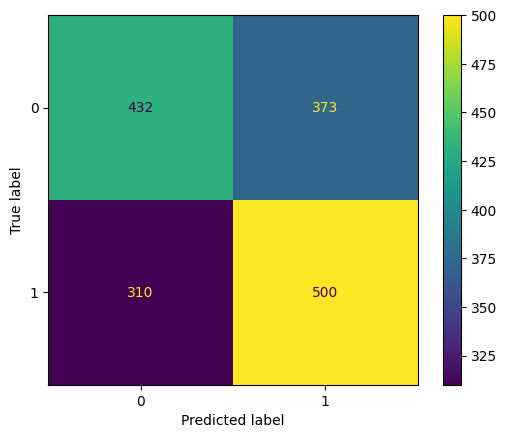

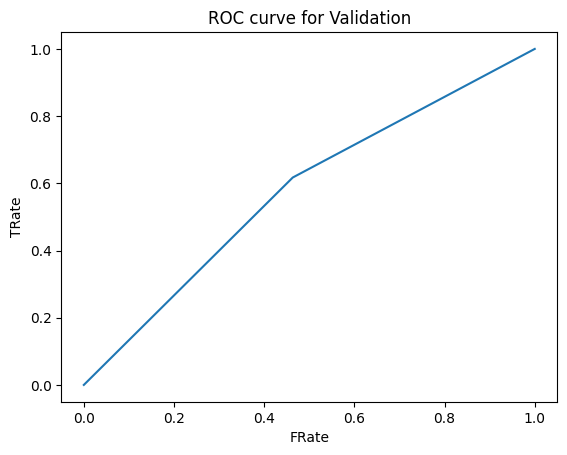


AUC Validation Metric:  0.5769649566751016


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--LR Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr)
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.62      0.57      0.60       817
           1       0.60      0.64      0.62       799

    accuracy                           0.61      1616
   macro avg       0.61      0.61      0.61      1616
weighted avg       0.61      0.61      0.61      1616


Test Time--LR Classifier : 0.026140689849853516 



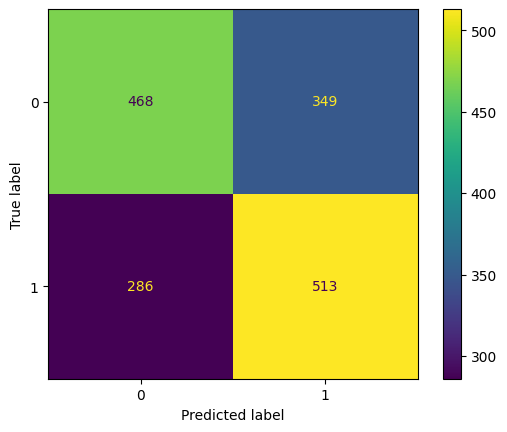

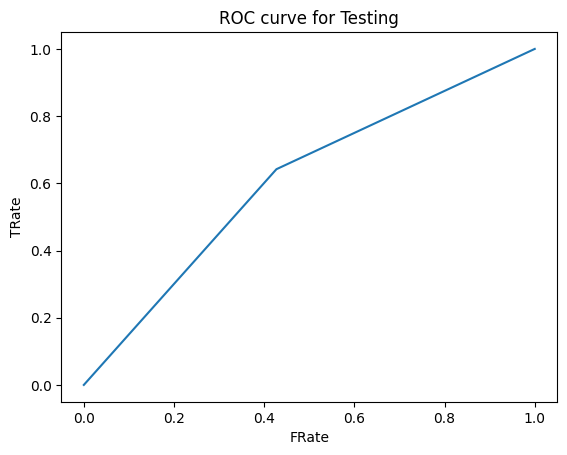


AUC Testing Metric:  0.6074399915438974


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--LR Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr)
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier as Dimen_ReductDTC

Dimen_Reducthyprms = {
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'splitter' : ['best', 'random'],
                       'max_depth' : [1, 5, 10, 50, None]
                       }

Dimenredmd = Dimen_ReductDTC()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- DT:")
print(Dimenredmd.best_params_)

best Params -- DT:
{'criterion': 'log_loss', 'max_depth': 50, 'splitter': 'best'}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductDTC(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--DT classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--DT classifier   : 0.6251158714294434 



              precision    recall  f1-score   support

           0       0.82      0.75      0.78       805
           1       0.77      0.84      0.80       810

    accuracy                           0.79      1615
   macro avg       0.79      0.79      0.79      1615
weighted avg       0.79      0.79      0.79      1615


Validate Time--DT Classifier : 0.015802383422851562 



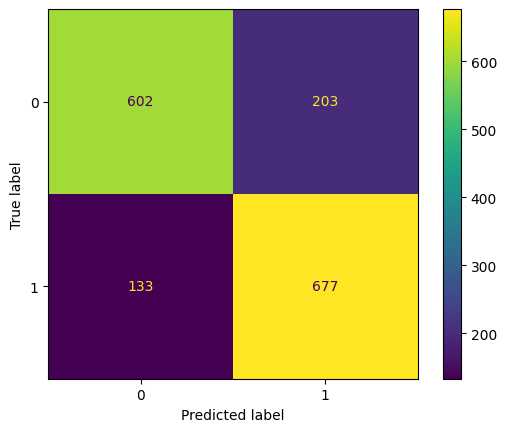

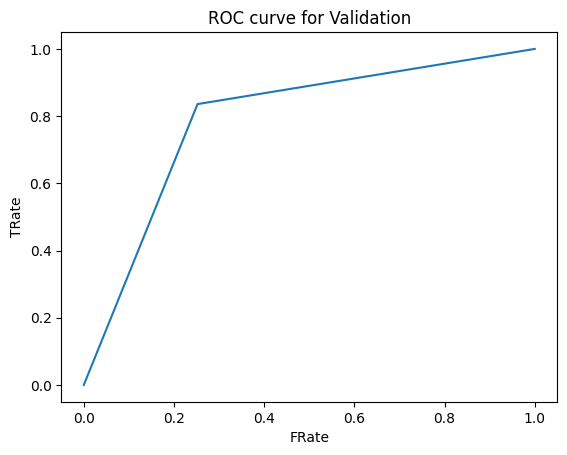


AUC Validation Metric:  0.7918142780461621


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--DT Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr)
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       817
           1       0.76      0.80      0.78       799

    accuracy                           0.77      1616
   macro avg       0.77      0.77      0.77      1616
weighted avg       0.77      0.77      0.77      1616


Test Time--DT Classifier : 0.012614250183105469 



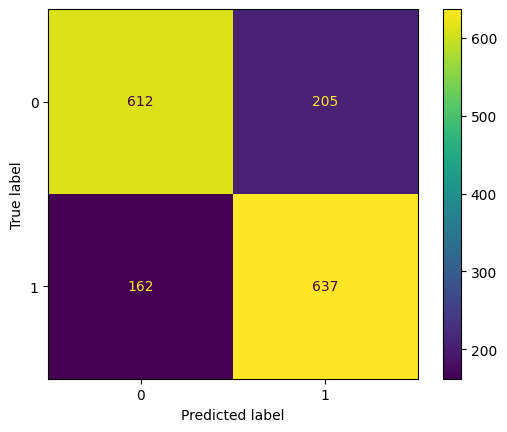

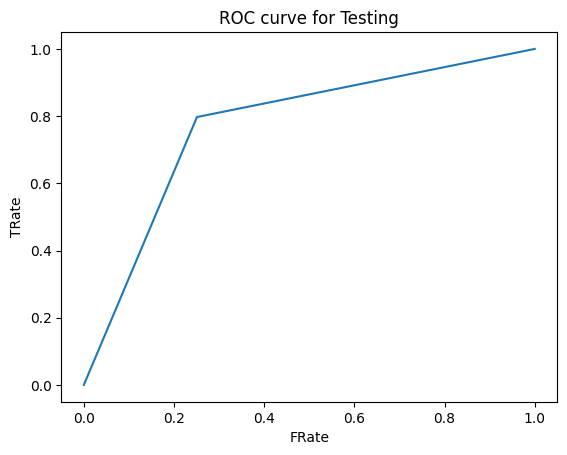


AUC Testing Metric:  0.7731642827708441


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--DT Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr)
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Balanced Random Forest Classifier

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier as Dimen_ReductBRF


Dimen_Reducthyprms = {
                       'n_estimators' : [10, 50, 100, 200],
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'max_depth' : [1, 5, 50, None],
                       'max_features': [None, 'sqrt', 'log2']
                       }

Dimenredmd = Dimen_ReductBRF()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- BRF:")
print(Dimenredmd.best_params_)

best Params -- BRF:
{'criterion': 'log_loss', 'max_depth': 50, 'max_features': None, 'n_estimators': 200}


In [ ]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductBRF(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--BRF classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--BRF classifier   : 86.08600568771362 



              precision    recall  f1-score   support

           0       0.88      0.79      0.83       805
           1       0.81      0.89      0.85       810

    accuracy                           0.84      1615
   macro avg       0.85      0.84      0.84      1615
weighted avg       0.84      0.84      0.84      1615


Validate Time--BRF Classifier : 0.11435437202453613 



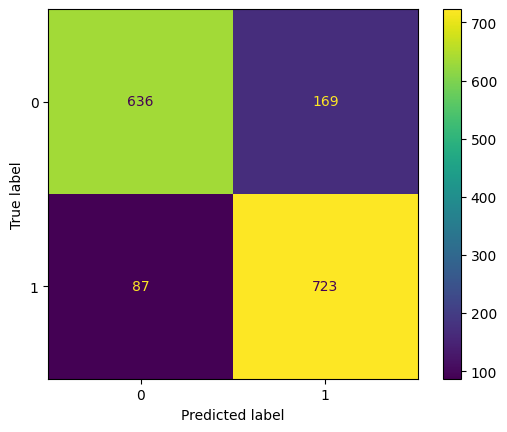

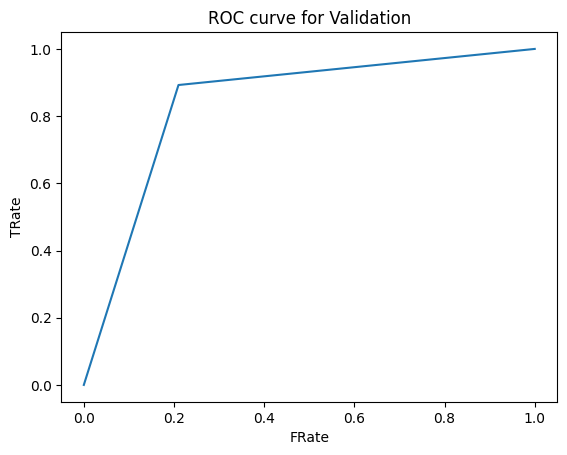


AUC Validation Metric:  0.8413273521969175


In [ ]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--BRF Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr)
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       817
           1       0.83      0.87      0.85       799

    accuracy                           0.85      1616
   macro avg       0.85      0.85      0.85      1616
weighted avg       0.85      0.85      0.85      1616


Test Time--BRF Classifier : 0.13205265998840332 



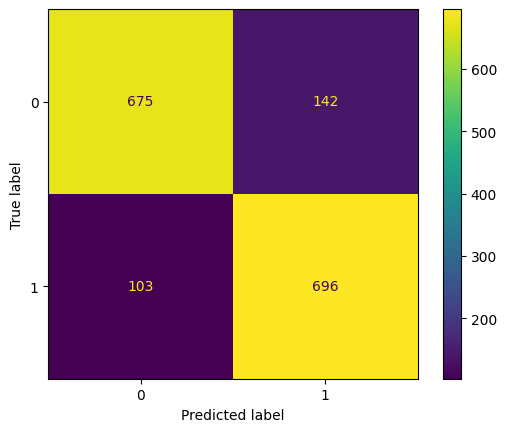

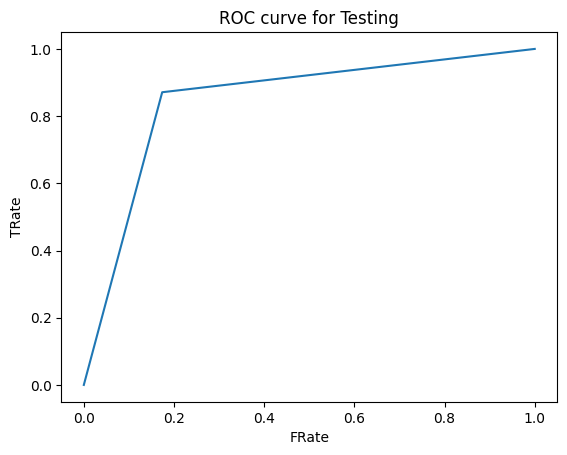


AUC Testing Metric:  0.8486411257646109


In [ ]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--BRF Classifier :", dimenrednd2-dimenrednd1,"\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix = dimenreductcnx, display_labels = [0, 1]).plot()
Dimen_ReductMn.show()


fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst, dimenrdcpr)
Dimen_ReductMn.plot(fp, tp)
Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr)
print("\nAUC Testing Metric: ", DimenRedtAuc)